# 04 — Models: infection-concern classification

Binary task: predict **`source_infection_label`** (1 = High Infection Concern,
0 = Low Infection Concern) from the synthetic note text (**`clinical_note`**).

The synthetic corpus comes straight from notebook 03 (Ollama):
`data/02_clinical_notes/ollama/clinical_notes.jsonl`. This notebook:

1. runs a quick **EDA** to understand the corpus,
2. makes a **patient-disjoint** train / validation / test split
   (grouped by `source_subject_id`, so no patient appears in two splits),
3. trains and compares several models.

Models:
**PubMedBERT** and **GPT-2** — fine-tuned via one reusable
   `train_transformer(model_name)`.


## Setup — load the synthetic corpus & evaluation helpers

In [1]:
! pip install torch transformers
! pip install transformers[torch]
! pip install 'accelerate>=1.1.0'

In [2]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# -----------------------------
# Paths and constants
# -----------------------------
ROOT = Path.cwd()
if not (ROOT / "data").exists() and (ROOT.parent / "data").exists():
    ROOT = ROOT.parent

DATA_DIR = ROOT / "data"
NOTES_PATH = DATA_DIR / "02_clinical_notes" / "ollama" / "clinical_notes.jsonl"
SPLITS_DIR = DATA_DIR / "03_notes_splits"
REPORTS_DIR = ROOT / "reports"
REPORTS_DIR.mkdir(exist_ok=True)

TEXT_FIELD = "clinical_note"
LABEL_FIELD = "source_infection_label"
GROUP_FIELD = "source_subject_id"

results = {}

# -----------------------------
# Load data
# -----------------------------
def load_jsonl(path):
    with Path(path).open(encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

if not NOTES_PATH.exists():
    raise FileNotFoundError(f"Could not find: {NOTES_PATH}")

notes = load_jsonl(NOTES_PATH)
print("Loaded", len(notes), "synthetic notes from:", NOTES_PATH)

# -----------------------------
# Evaluation functions
# -----------------------------
def evaluate(model_name, split, y_true, y_pred, y_score=None, show_report=False):
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="binary", zero_division=0
    )
    auc = (
        roc_auc_score(y_true, y_score)
        if (y_score is not None and len(set(y_true)) > 1)
        else float("nan")
    )
    row = {"precision_high": p, "recall_high": r, "f1_high": f1, "roc_auc": auc}
    results.setdefault(model_name, {})[split] = row

    print(
        f"[{model_name} | {split}] "
        f"precision_HIGH={p:.3f}  recall_HIGH={r:.3f}  f1_HIGH={f1:.3f}  auc={auc:.3f}"
    )

    if show_report:
        print(classification_report(y_true, y_pred, target_names=["LOW", "HIGH"], zero_division=0))
        print("confusion matrix (rows=true LOW/HIGH, cols=pred LOW/HIGH):")
        print(confusion_matrix(y_true, y_pred))
    return row


def plot_confusion_matrix(model_name, split, y_true, y_pred):
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=["LOW", "HIGH"],
        cmap="Blues",
        values_format="d"
    )

    plt.title(f"Confusion Matrix - {model_name} ({split})")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f"confusion_matrix_{model_name}_{split}.png", dpi=120)
    plt.show()


def evaluate_by_infection_type(model_name, split_name, df, y_true, y_pred):
    analysis = df.copy()
    analysis["true_label"] = y_true
    analysis["pred_label"] = y_pred
    analysis["correct"] = analysis["true_label"] == analysis["pred_label"]

    type_summary = (
        analysis
        .groupby("infection_type")
        .agg(
            total=("correct", "count"),
            correct=("correct", "sum"),
            accuracy=("correct", "mean"),
            high_cases=("true_label", "sum"),
            high_predicted=("pred_label", "sum")
        )
        .reset_index()
    )

    type_summary["accuracy"] = type_summary["accuracy"].round(3)
    # Same number as "accuracy", just expressed as 0-100 for a clearer y-axis
    # ("% correct" reads more directly than a 0-1 fraction on a bar chart).
    type_summary["pct_correct"] = (type_summary["accuracy"] * 100).round(1)

    print(f"\nPerformance by infection type - {model_name} ({split_name})")
    print(type_summary.sort_values("accuracy", ascending=False).to_string(index=False))

    type_summary.to_csv(
        REPORTS_DIR / f"infection_type_performance_{model_name}_{split_name}.csv",
        index=False
    )

    plt.figure(figsize=(10, 5))
    plt.bar(type_summary["infection_type"], type_summary["pct_correct"])
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 100)
    plt.ylabel("% Correct")
    plt.title(f"% Correct by Infection Type - {model_name} ({split_name})")
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / f"infection_type_accuracy_{model_name}_{split_name}.png", dpi=120)
    plt.show()

    # --- Predicted LOW/HIGH counts by infection category -----------------------
    # This is the model's-eye view, as opposed to the ground-truth heatmap built
    # earlier (before any model ran): how many notes of each infection type did
    # THIS model actually call LOW vs. HIGH. Comparing the two side by side shows
    # exactly where a category's true cases get mis-predicted to the other class.
    pred_crosstab = pd.crosstab(analysis["infection_type"], analysis["pred_label"])
    pred_crosstab = pred_crosstab.rename(columns={0: "Predicted LOW", 1: "Predicted HIGH"})
    for col in ["Predicted LOW", "Predicted HIGH"]:
        if col not in pred_crosstab.columns:
            pred_crosstab[col] = 0
    pred_crosstab = pred_crosstab[["Predicted LOW", "Predicted HIGH"]]

    plt.figure(figsize=(8, 6))
    sns.heatmap(pred_crosstab, annot=True, fmt="d", cmap="Blues", cbar=True)
    plt.title(f"Predicted LOW vs HIGH by Infection Type - {model_name} ({split_name})")
    plt.xlabel("Model prediction")
    plt.ylabel("Infection Type")
    plt.tight_layout()
    pred_heatmap_path = REPORTS_DIR / f"infection_type_predicted_label_{model_name}_{split_name}.png"
    plt.savefig(pred_heatmap_path, dpi=120, bbox_inches="tight")
    print("Saved:", pred_heatmap_path)
    plt.show()

    return type_summary


def find_best_threshold(y_true, scores, optimize="macro"):
    """Sweep thresholds and pick the one maximizing a chosen F1 variant.

    optimize="macro" (default): balances LOW and HIGH equally. Use this unless
    you specifically want to prioritize catching HIGH cases at LOW's expense.
    optimize="high": the original behavior — F1 for the HIGH class only. This
    tends to push the threshold down, over-predicting HIGH and hurting LOW
    precision/recall — which matches the "LOW is half right, half wrong"
    pattern.
    """
    best_t = 0.5
    best_f1 = 0

    for t in np.arange(0.1, 0.9, 0.01):
        pred = (scores >= t).astype(int)
        f1 = f1_score(y_true, pred, average="macro") if optimize == "macro" else f1_score(y_true, pred)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    return best_t, best_f1


def evaluate_predictor(model_name, predict_scores, threshold_metric="macro"):
    """threshold_metric="macro" balances LOW and HIGH when picking the decision
    threshold (recommended default). Pass "high" to reproduce the original
    behavior of optimizing only the HIGH-class F1."""
    X_val, y_val = EVAL_SETS["validation"]
    val_scores = np.asarray(predict_scores(X_val))

    best_t, best_val_f1 = find_best_threshold(y_val, val_scores, optimize=threshold_metric)

    print(f"\n[{model_name}] best threshold on validation ({threshold_metric}-F1) = {best_t:.2f}")
    print(f"[{model_name}] best validation {threshold_metric}-F1 = {best_val_f1:.3f}\n")

    for split, (Xs, ys) in EVAL_SETS.items():
        score = np.asarray(predict_scores(Xs))
        pred = (score >= best_t).astype(int)

        evaluate(
            model_name,
            split,
            ys,
            pred,
            score,
            show_report=(split == "test")
        )

        if split == "test":
            plot_confusion_matrix(model_name, split, ys, pred)

            if "test_df" in globals():
                evaluate_by_infection_type(
                    model_name,
                    split,
                    test_df,
                    ys,
                    pred
                )
            else:
                print("test_df was not found, so infection_type analysis was skipped.")

Loaded 3300 synthetic notes from: /content/data/02_clinical_notes/ollama/clinical_notes.jsonl


## EDA — understand the synthetic corpus (before splitting)

A quick look at the notes we are about to model: label balance, which infection
categories the HIGH notes come from, symptom-severity mix per label, note length,
writing-style variety, and how many notes each patient contributes. This tells us
what signal (and what imbalance / leakage risk) the classifiers will face. A figure
is saved to `reports/eda_synthetic_notes.png`.

Notes: 3300 | unique patients: 100 | unique admissions: 275
Notes per patient: mean 33.0, min 12, max 240

Label balance (is_infection):
is_infection
LOW (0)     1740
HIGH (1)    1560

Infection source (HIGH notes only):
infection_source
Other/Mixed           744
Urinary               276
Skin/Soft tissue      228
Respiratory           216
Bloodstream/Sepsis     96

Symptom severity by label:
symptom_severity        mild  moderate   no
label                                      
High Infection Concern   634       689  237
Low Infection Concern    592       262  886

Writing style:
writing_style
Clinical case summary      1176
Physician progress note    1072
Nursing handoff note       1052

Note length (characters) by label:
                         mean    min    max
label                                      
High Infection Concern  286.1   93.0  628.0
Low Infection Concern   242.1  102.0  565.0

Notes flagged with residual leakage terms: 8


/tmp/ipykernel_441/3722815809.py:62: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 0].boxplot([eda.loc[eda.label == lb, "char_len"] for lb in labels_order],


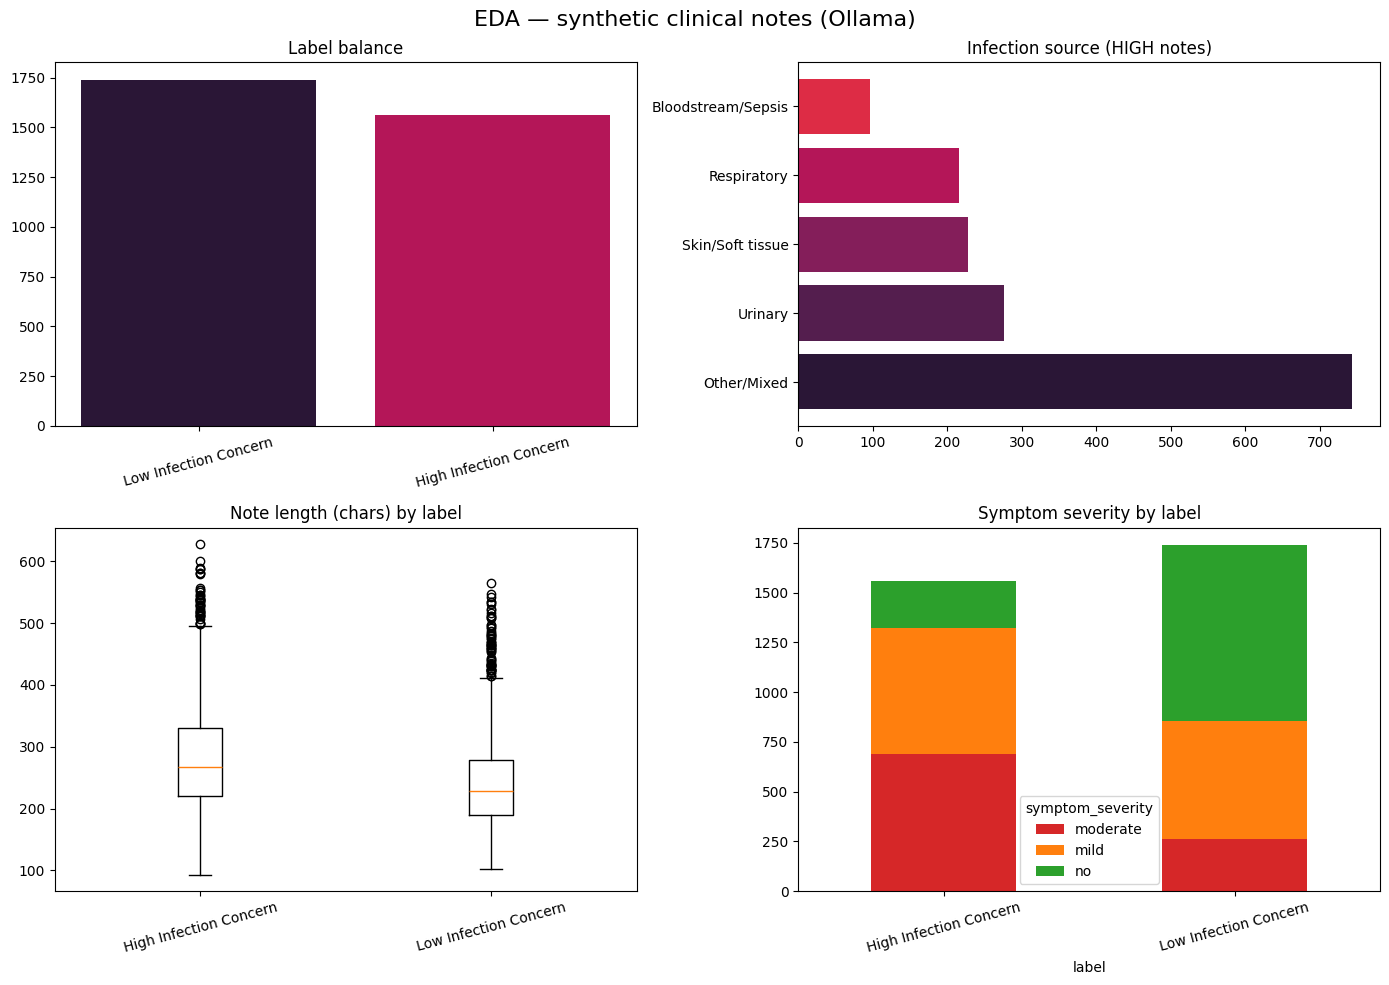


Saved EDA figure to: /content/reports/eda_synthetic_notes.png


In [3]:
# Tidy DataFrame for exploration.
eda = pd.DataFrame({
    "text": [n[TEXT_FIELD] for n in notes],
    "is_infection": [int(n[LABEL_FIELD]) for n in notes],
    "label": [n.get("label") for n in notes],
    "infection_source": [n.get("infection_source") for n in notes],
    "symptom_severity": [n.get("symptom_severity") for n in notes],
    "writing_style": [n.get("writing_style") for n in notes],
    "subject_id": [n.get(GROUP_FIELD) for n in notes],
    "hadm_id": [n.get("source_hadm_id") for n in notes],
    "n_leaked": [len(n.get("leaked_terms") or []) for n in notes],
})
eda["char_len"] = eda["text"].str.len()
eda["word_len"] = eda["text"].str.split().map(len)

notes_per_patient = eda.groupby("subject_id").size()

print("Notes:", len(eda),
      "| unique patients:", eda["subject_id"].nunique(),
      "| unique admissions:", eda["hadm_id"].nunique())
print(f"Notes per patient: mean {notes_per_patient.mean():.1f}, "
      f"min {notes_per_patient.min()}, max {notes_per_patient.max()}")

print("\nLabel balance (is_infection):")
print(eda["is_infection"].value_counts().rename({0: "LOW (0)", 1: "HIGH (1)"}).to_string())

print("\nInfection source (HIGH notes only):")
print(eda.loc[eda.is_infection == 1, "infection_source"].value_counts().to_string())

print("\nSymptom severity by label:")
print(pd.crosstab(eda["label"], eda["symptom_severity"]).to_string())

print("\nWriting style:")
print(eda["writing_style"].value_counts().to_string())

print("\nNote length (characters) by label:")
print(eda.groupby("label")["char_len"].describe()[["mean", "min", "max"]].round(1).to_string())

print("\nNotes flagged with residual leakage terms:", int((eda["n_leaked"] > 0).sum()))

# --- Visual overview -------------------------------------------------------
# Shared purple -> coral palette, matching the style of the notebook 00 MIMIC-IV
# EDA (reports/eda_mimic.png), so the two EDA figures in the final report look
# like they belong to the same project instead of using different default colors.
ROCKET = sns.color_palette("rocket", 8)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("EDA — synthetic clinical notes (Ollama)", fontsize=16)

label_counts = eda["label"].value_counts()
axes[0, 0].bar(label_counts.index.astype(str), label_counts.values,
               color=[ROCKET[0], ROCKET[3]][:len(label_counts)])
axes[0, 0].set_title("Label balance")
axes[0, 0].tick_params(axis="x", rotation=15)

source_counts = eda.loc[eda.is_infection == 1, "infection_source"].value_counts()
axes[0, 1].barh(source_counts.index.astype(str), source_counts.values,
                 color=ROCKET[:len(source_counts)])
axes[0, 1].set_title("Infection source (HIGH notes)")

labels_order = list(eda["label"].unique())
axes[1, 0].boxplot([eda.loc[eda.label == lb, "char_len"] for lb in labels_order],
                   labels=labels_order)
axes[1, 0].set_title("Note length (chars) by label")
axes[1, 0].tick_params(axis="x", rotation=15)

# Symptom severity by label — stacked bar, ordered Moderate (bottom) -> Mild ->
# No (top), colored red/orange/green so the severity reads at a glance.
# Match actual category strings case-insensitively rather than hardcoding case,
# since the raw data's exact spelling isn't guaranteed.
severity_crosstab = pd.crosstab(eda["label"], eda["symptom_severity"])
SEVERITY_ORDER = ["moderate", "mild", "no"]  # bottom -> top of the stack
SEVERITY_COLORS = {"moderate": "#d62728", "mild": "#ff7f0e", "no": "#2ca02c"}  # red, orange, green

ordered_cols = []
color_list = []
for key in SEVERITY_ORDER:
    match = next((c for c in severity_crosstab.columns if str(c).strip().lower().startswith(key)), None)
    if match is not None:
        ordered_cols.append(match)
        color_list.append(SEVERITY_COLORS[key])
# Any remaining/unexpected category not in the map above still gets plotted, just appended on top.
leftover = [c for c in severity_crosstab.columns if c not in ordered_cols]
ordered_cols += leftover
color_list += [ROCKET[5]] * len(leftover)

severity_crosstab = severity_crosstab[ordered_cols]
severity_crosstab.plot(kind="bar", stacked=True, ax=axes[1, 1], color=color_list)
axes[1, 1].set_title("Symptom severity by label")
axes[1, 1].tick_params(axis="x", rotation=15)

plt.tight_layout()
(ROOT / "reports").mkdir(exist_ok=True)
eda_fig_path = ROOT / "reports" / "eda_synthetic_notes.png"
plt.savefig(eda_fig_path, dpi=120, bbox_inches="tight")
plt.show()
print("\nSaved EDA figure to:", eda_fig_path)


## Split — patient-disjoint, label-stratified train / validation / test

We split **by patient** (`source_subject_id`), not by note. The corpus has ~3,300 notes
from only ~100 patients, so a plain random split would put the *same patient* in both
train and test and inflate the scores. `StratifiedGroupKFold` keeps every patient in one
split **and** balances the HIGH/LOW ratio across splits, so evaluation is both honest and
not skewed by class imbalance. The three splits are saved to `data/03_notes_splits/`.

In [10]:
from sklearn.model_selection import StratifiedGroupKFold

# Arrays aligned with `notes`.
X = np.array([n[TEXT_FIELD] for n in notes], dtype=object)
y = np.array([int(n[LABEL_FIELD]) for n in notes])
groups = np.array([n[GROUP_FIELD] for n in notes])

# Patient-disjoint AND label-stratified split. StratifiedGroupKFold keeps every
# patient (source_subject_id) inside a single fold while balancing the HIGH/LOW
# ratio across folds. With n_splits=7 each fold is ~1/7 of the data: we take one
# fold as test, one as validation, and the remaining ~5/7 as train.
# Grouping prevents patient leakage; stratifying keeps the labels balanced.
sgkf = StratifiedGroupKFold(n_splits=7, shuffle=True, random_state=42)
fold_test_idx = [test for _, test in sgkf.split(X, y, groups)]

test_idx = fold_test_idx[0]
val_idx = fold_test_idx[1]
in_eval = np.zeros(len(y), dtype=bool)
in_eval[test_idx] = True
in_eval[val_idx] = True
train_idx = np.where(~in_eval)[0]


# Several synthetic notes can share the same source admission (source_hadm_id) —
# e.g. multiple writing-style variants generated from one clinical profile. Left
# uncapped, an admission with many variants would dominate the training set and
# the model could learn to recognise phrasing quirks of that one admission rather
# than genuine infection signal. Capping at 3 keeps some of that variety (useful
# for training) without letting any single admission overwhelm the class balance.
MAX_NOTES_PER_ORIGINAL = 3

train_notes_idx = pd.DataFrame({
    "idx": train_idx,
    "source_hadm_id": [notes[i]["source_hadm_id"] for i in train_idx]
})

train_idx = (
    train_notes_idx
    .groupby("source_hadm_id", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), MAX_NOTES_PER_ORIGINAL),
        random_state=42
    ))
    ["idx"]
    .to_numpy()
)



X_train, y_train = X[train_idx].tolist(), y[train_idx]
X_val, y_val = X[val_idx].tolist(), y[val_idx]
X_test, y_test = X[test_idx].tolist(), y[test_idx]

EVAL_SETS = {
    "validation":     (X_val, y_val),
    "test": (X_test, y_test),
}

# Safety check: patient groups must be disjoint across splits.
g_train, g_val, g_test = set(groups[train_idx]), set(groups[val_idx]), set(groups[test_idx])
assert not (g_train & g_val) and not (g_train & g_test) and not (g_val & g_test), \
    "patient overlap between splits!"


def _bal(name, ys):
    ys = np.asarray(ys)
    print(f"{name:16s} n={len(ys):4d}  HIGH={int(ys.sum()):4d}  LOW={int((1 - ys).sum()):4d}")


print("Patient-disjoint, label-stratified splits:")
_bal("train", y_train)
_bal("validation", y_val)
_bal("test", y_test)
print(f"Patients -> train: {len(g_train)}  val: {len(g_val)}  test: {len(g_test)}")

# Persist the split so the run is reproducible and can be reused downstream.
SPLITS_DIR.mkdir(parents=True, exist_ok=True)
for name, idx in [("train", train_idx), ("validation", val_idx), ("test", test_idx)]:
    with (SPLITS_DIR / f"{name}.jsonl").open("w", encoding="utf-8") as f:
        for i in idx:
            f.write(json.dumps({
                TEXT_FIELD: notes[i][TEXT_FIELD],
                LABEL_FIELD: int(notes[i][LABEL_FIELD]),
                GROUP_FIELD: notes[i][GROUP_FIELD],
            }, ensure_ascii=False) + "\n")
print("Saved splits to:", SPLITS_DIR)


Patient-disjoint, label-stratified splits:
train            n= 558  HIGH= 237  LOW= 321
validation       n= 720  HIGH= 432  LOW= 288
test             n= 348  HIGH= 180  LOW= 168
Patients -> train: 74  val: 17  test: 9
Saved splits to: /content/data/03_notes_splits


/tmp/ipykernel_441/2030042035.py:40: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


## Build `test_df` — needed for the infection-type breakdown

Small lookup DataFrame for the `test` split only: the note text, its true
label, and its infection type (renamed from `infection_source` here just for
readability). Built right after the split, once `test_idx`/`X_test`/`y_test`
exist, so it's already available when `evaluate_predictor` runs during
training below — no more "test_df was not found" skips.


In [5]:
test_df = pd.DataFrame({
    "summary": X_test,
    "label": y_test,
    "infection_type": [notes[i].get("infection_source", "unknown") for i in test_idx]
})
print(test_df["infection_type"].value_counts())


infection_type
none                  168
Other/Mixed            96
Bloodstream/Sepsis     36
Skin/Soft tissue       36
Urinary                12
Name: count, dtype: int64


### Models — PubMedBERT & GPT-2

One reusable `train_transformer(model_name)` fine-tunes any HuggingFace
sequence-classification model. We use it for **PubMedBERT** and for a **simple GPT
(GPT-2)** — the only difference is the model name (GPT-2 has no pad token, which
the function handles).

> Needs `pip install torch transformers`. If they're missing, these cells print a
> note and skip, leaving Model 1 intact.

In [11]:
# pip install torch transformers
from torch.nn import CrossEntropyLoss

try:
    import torch
    from torch.utils.data import Dataset
    from transformers import (
          AutoTokenizer,
          AutoModelForSequenceClassification,
          TrainingArguments,
          Trainer,
          EarlyStoppingCallback
          )
    HAS_TRANSFORMERS = True
except Exception:
    HAS_TRANSFORMERS = False
    Dataset = object   # fallback so the class below still defines when torch is absent
    print("torch/transformers not installed -> BERT & GPT-2 cells will be skipped.")
    print("Install with:  pip install torch transformers")

import matplotlib.pyplot as plt


class TextDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]))
        return item


class WeightedTrainer(Trainer):
    """Trainer that supports class weights in the cross-entropy loss.
    Balances the loss when HIGH and LOW cases are unequal in size."""

    def __init__(self, class_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        if self.class_weights is not None:
            weights = self.class_weights.to(logits.device)
            loss_fn = CrossEntropyLoss(weight=weights)
        else:
            loss_fn = CrossEntropyLoss()
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss


def plot_training_curves(trainer, model_name):
    """Plot training loss and validation loss across the training run.

    Reads from trainer.state.log_history — a list of dicts logged during training.
    Training loss entries contain 'loss' + 'epoch' (logged every logging_steps).
    Validation loss entries contain 'eval_loss' + 'epoch' (logged every eval_strategy).
    """
    history = trainer.state.log_history

    # Separate training-loss entries from validation-loss entries.
    train_epochs = [e["epoch"] for e in history if "loss" in e and "eval_loss" not in e]
    train_losses = [e["loss"] for e in history if "loss" in e and "eval_loss" not in e]

    val_epochs = [e["epoch"] for e in history if "eval_loss" in e]
    val_losses = [e["eval_loss"] for e in history if "eval_loss" in e]

    if not train_losses and not val_losses:
        print(f"[{model_name}] no loss data to plot.")
        return

    fig, ax = plt.subplots(figsize=(9, 5))

    if train_losses:
        ax.plot(train_epochs, train_losses, label="Training loss",
                color="tab:blue", alpha=0.6, linewidth=1.5)

    if val_losses:
        ax.plot(val_epochs, val_losses, label="Validation loss",
                color="tab:red", marker="o", markersize=8, linewidth=2)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_ylim(0, 3)
    ax.set_title(f"Training progression: {model_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # If validation loss is available, mark the best (lowest) validation epoch.
    if val_losses:
        best_idx = val_losses.index(min(val_losses))
        best_epoch = val_epochs[best_idx]
        best_val = val_losses[best_idx]
        ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.5,
                   label=f"Best val epoch ({best_epoch:.1f}, loss={best_val:.3f})")
        ax.legend()

    plt.tight_layout()

    # Save alongside the confusion matrices — model_name can contain "/" (e.g.
    # HuggingFace repo ids like "microsoft/BiomedNLP-..."), so sanitize it first.
    safe_name = model_name.replace("/", "_")
    curve_path = REPORTS_DIR / f"training_curve_{safe_name}.png"
    plt.savefig(curve_path, dpi=120, bbox_inches="tight")
    print(f"[{model_name}] saved training curve to: {curve_path}")

    plt.show()

    # Also print a brief summary in text form.
    print(f"\n[{model_name}] Training summary:")
    if train_losses:
        print(f"  Final training loss:   {train_losses[-1]:.4f}")
    if val_losses:
        print(f"  Best validation loss:  {min(val_losses):.4f} at epoch {val_epochs[val_losses.index(min(val_losses))]:.1f}")
        print(f"  Final validation loss: {val_losses[-1]:.4f}")


def train_transformer(model_name, epochs=3, max_len=384, batch_size=8, lr=2e-5,
                       plot_curves=True):
    """Fine-tune `model_name` for binary classification.
    Returns predict_scores(texts) -> np.array P(HIGH)."""
    if not HAS_TRANSFORMERS:
        print(f"[skip] {model_name}: transformers not available")
        return None

    tok = AutoTokenizer.from_pretrained(model_name)
    if tok.pad_token is None:                 # GPT-2 and other decoder models
        tok.pad_token = tok.eos_token

    def enc(texts):
        return tok(list(texts), truncation=True, padding="max_length", max_length=max_len)

    ds_train = TextDataset(enc(X_train), y_train)
    ds_val = TextDataset(enc(X_val), y_val)

    model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)
    model.config.pad_token_id = tok.pad_token_id

    # Compute class weights from the training labels.
    # Formula: weight_c = N / (K * n_c)  where K=2 classes, n_c = count of class c.
    n_high = int(sum(y_train))
    n_low = len(y_train) - n_high
    class_weights = torch.tensor(
        [len(y_train) / (2 * n_low), len(y_train) / (2 * n_high)],
        dtype=torch.float,
    )
    print(f"[{model_name}] class weights -> LOW={class_weights[0]:.3f}, HIGH={class_weights[1]:.3f}")

    args = TrainingArguments(
        output_dir=f"models/{model_name.replace('/', '_')}",
        num_train_epochs=epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=32,
        learning_rate=lr,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_steps=50,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        save_total_limit=2,
        report_to="none",
        seed=42,
    )

    trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=ds_train,
    eval_dataset=ds_val,
    class_weights=class_weights,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
    )
    trainer.train()

    # Plot training and validation loss curves after training completes.
    if plot_curves:
        plot_training_curves(trainer, model_name)

    def predict_scores(texts):
        out = trainer.predict(TextDataset(enc(texts), [0] * len(texts)))
        probs = torch.softmax(torch.tensor(out.predictions), dim=-1).numpy()
        return probs[:, 1]

    return predict_scores

### Model 1 — PubMedBERT


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect ide

[microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext] class weights -> LOW=0.869, HIGH=1.177


Epoch,Training Loss,Validation Loss
1,0.687087,0.782861
2,0.617673,0.643409
3,0.475482,0.642122
4,0.445627,0.720049
5,0.350536,0.963253
6,0.239352,1.464988
7,0.189976,1.424890


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext] saved training curve to: /content/reports/training_curve_microsoft_BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext.png


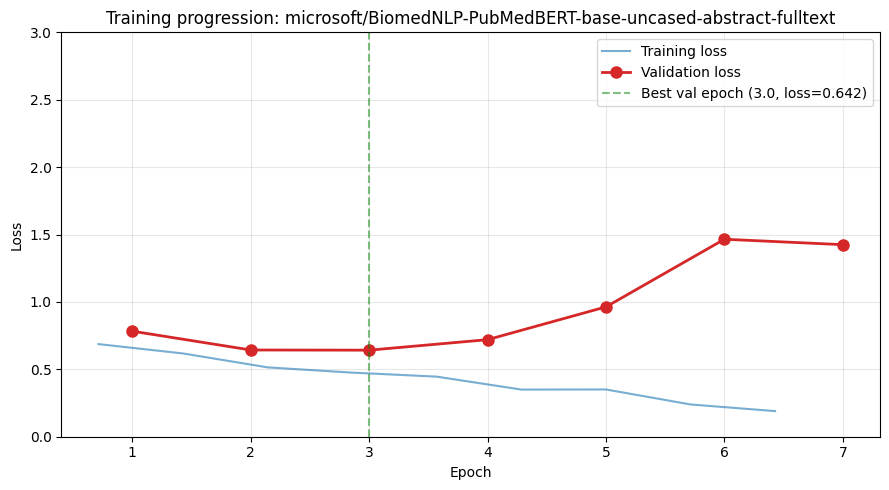


[microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext] Training summary:
  Final training loss:   0.1900
  Best validation loss:  0.6421 at epoch 3.0
  Final validation loss: 1.4249



[pubmedbert] best threshold on validation (macro-F1) = 0.85
[pubmedbert] best validation macro-F1 = 0.689



[pubmedbert | validation] precision_HIGH=0.755  recall_HIGH=0.741  f1_HIGH=0.748  auc=0.757


[pubmedbert | test] precision_HIGH=0.722  recall_HIGH=0.839  f1_HIGH=0.776  auc=0.812
              precision    recall  f1-score   support

         LOW       0.79      0.65      0.72       168
        HIGH       0.72      0.84      0.78       180

    accuracy                           0.75       348
   macro avg       0.76      0.75      0.75       348
weighted avg       0.76      0.75      0.75       348

confusion matrix (rows=true LOW/HIGH, cols=pred LOW/HIGH):
[[110  58]
 [ 29 151]]


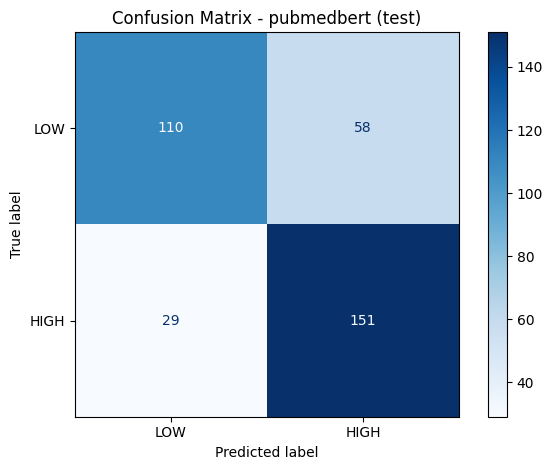


Performance by infection type - pubmedbert (test)
    infection_type  total  correct  accuracy  high_cases  high_predicted  pct_correct
Bloodstream/Sepsis     36       35     0.972          36              35         97.2
       Other/Mixed     96       83     0.865          96              83         86.5
           Urinary     12       10     0.833          12              10         83.3
              none    168      110     0.655           0              58         65.5
  Skin/Soft tissue     36       23     0.639          36              23         63.9


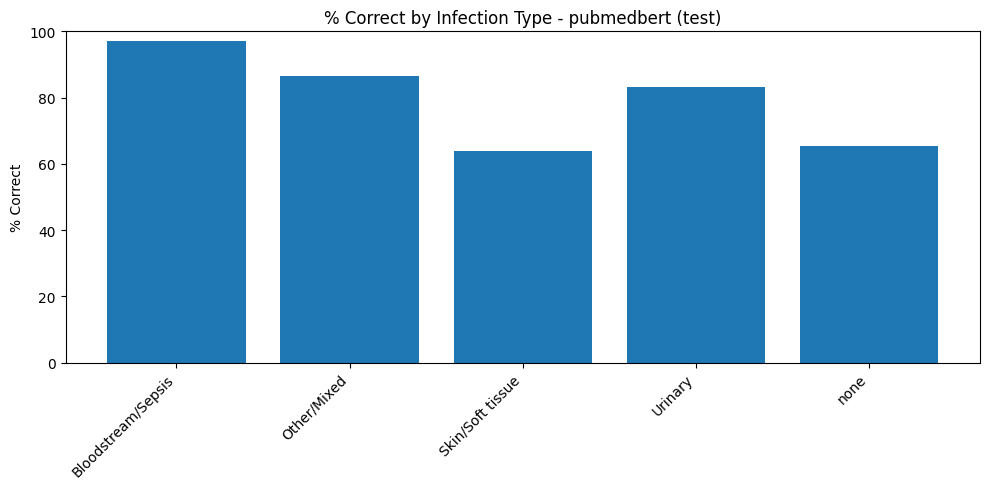

Saved: /content/reports/infection_type_predicted_label_pubmedbert_test.png


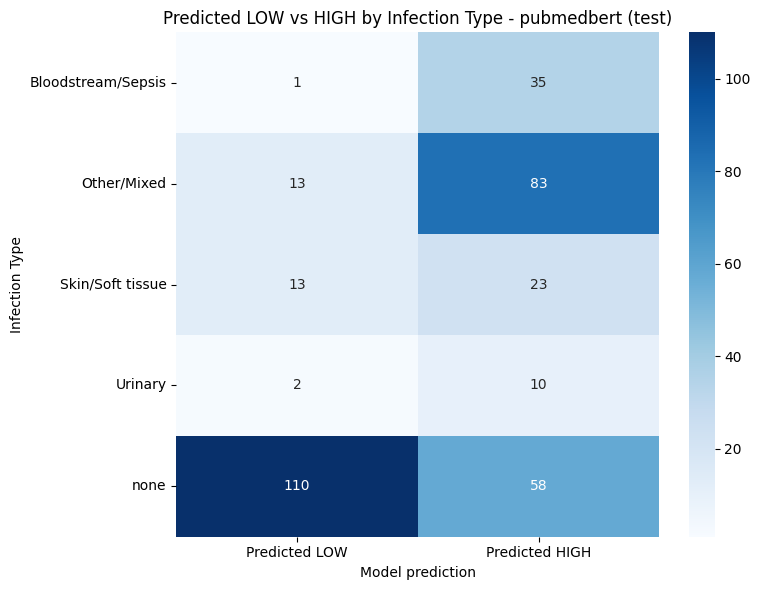

In [12]:
pubmedbert_predict = train_transformer(
    "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext",
    epochs=10,
    batch_size=8,
    max_len=384
)

if pubmedbert_predict is not None:
    evaluate_predictor("pubmedbert", pubmedbert_predict)

### Model 2 — Simple GPT (`gpt2`)

Same trainer, different name. GPT-2 as a sequence classifier (small batch + shorter length keep it light on CPU). It gets more epochs (10 vs. 5) than PubMedBERT because it isn't pretrained on biomedical text, so it needs more passes over the data to pick up the same signal; early stopping still cuts training short if validation loss stops improving.

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

[transformers] GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key          | Status  | 
-------------+---------+-
score.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


[gpt2] class weights -> LOW=0.869, HIGH=1.177


Epoch,Training Loss,Validation Loss
1,0.698882,0.952534
2,0.618990,0.811343
3,0.475315,0.748705
4,0.548998,1.229424
5,0.534960,1.159446
6,0.398025,1.146667
7,0.515792,1.362191


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[gpt2] saved training curve to: /content/reports/training_curve_gpt2.png


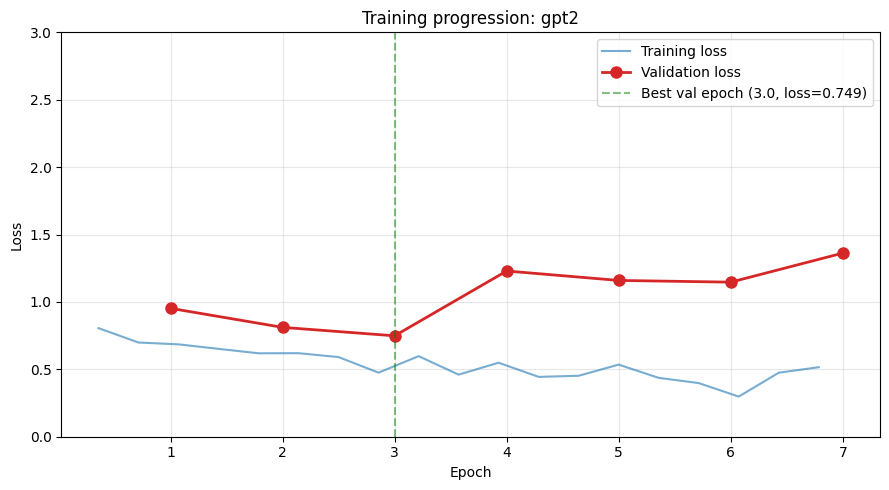


[gpt2] Training summary:
  Final training loss:   0.5158
  Best validation loss:  0.7487 at epoch 3.0
  Final validation loss: 1.3622



[gpt2] best threshold on validation (macro-F1) = 0.59
[gpt2] best validation macro-F1 = 0.686



[gpt2 | validation] precision_HIGH=0.744  recall_HIGH=0.762  f1_HIGH=0.753  auc=0.717


[gpt2 | test] precision_HIGH=0.679  recall_HIGH=0.811  f1_HIGH=0.739  auc=0.746
              precision    recall  f1-score   support

         LOW       0.74      0.59      0.66       168
        HIGH       0.68      0.81      0.74       180

    accuracy                           0.70       348
   macro avg       0.71      0.70      0.70       348
weighted avg       0.71      0.70      0.70       348

confusion matrix (rows=true LOW/HIGH, cols=pred LOW/HIGH):
[[ 99  69]
 [ 34 146]]


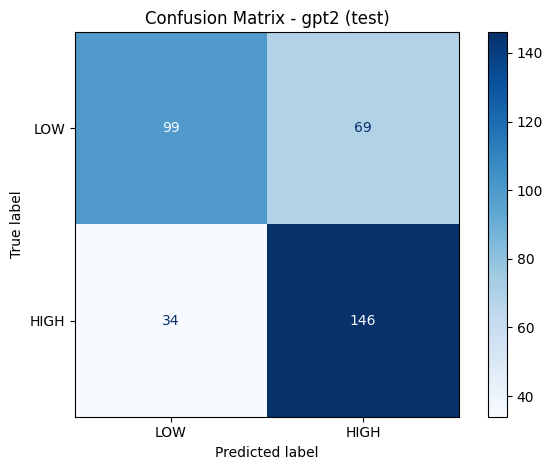


Performance by infection type - gpt2 (test)
    infection_type  total  correct  accuracy  high_cases  high_predicted  pct_correct
Bloodstream/Sepsis     36       33     0.917          36              33         91.7
           Urinary     12       11     0.917          12              11         91.7
       Other/Mixed     96       82     0.854          96              82         85.4
              none    168       99     0.589           0              69         58.9
  Skin/Soft tissue     36       20     0.556          36              20         55.6


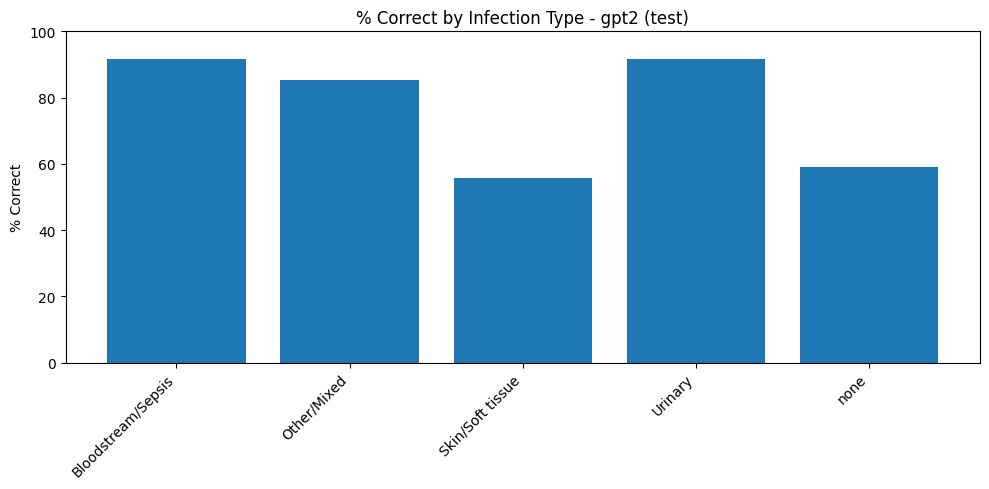

Saved: /content/reports/infection_type_predicted_label_gpt2_test.png


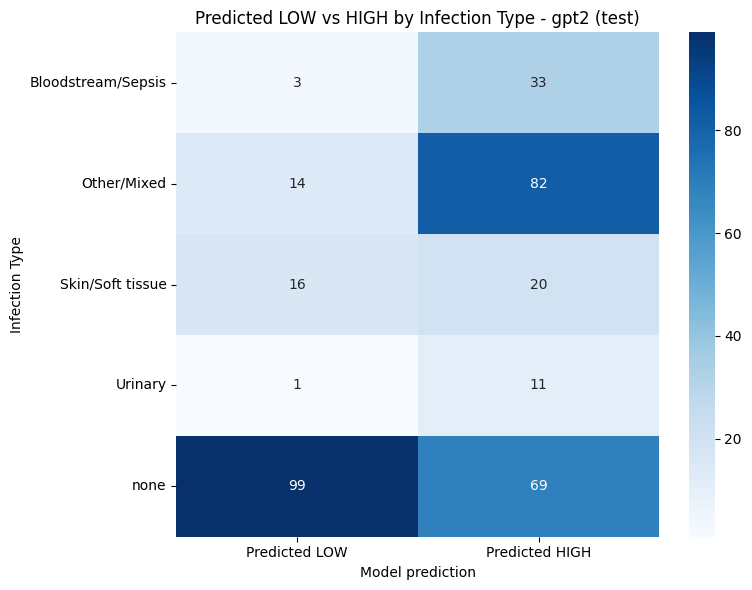

In [13]:
gpt2_predict = train_transformer(
    "gpt2",
    epochs=10,
    max_len=160,
    batch_size=4
)

if gpt2_predict is not None:
    evaluate_predictor("gpt2", gpt2_predict)

## Results comparison

Compares every model across the splits (threshold picked on `validation`, reported on
the held-out patient-disjoint `test` split). Saved to `reports/model_comparison_final.csv`.

In [14]:
rows = []
for model_name, splits in results.items():
    for split, m in splits.items():
        rows.append({
            "model": model_name,
            "split": split,
            "recall_high": round(m["recall_high"], 3),
            "precision_high": round(m["precision_high"], 3),
            "f1_high": round(m["f1_high"], 3),
            "roc_auc": round(m["roc_auc"], 3),
        })

comparison = pd.DataFrame(rows)

if not comparison.empty:
    comparison = comparison.sort_values(["split", "f1_high"], ascending=[True, False])
    print(comparison.to_string(index=False))
    Path("reports").mkdir(exist_ok=True)
    comparison.to_csv("reports/model_comparison_final.csv", index=False)
    print("\nSaved reports/model_comparison_final.csv")
else:
    print("No results yet - run the model cells above.")


     model      split  recall_high  precision_high  f1_high  roc_auc
pubmedbert       test        0.839           0.722    0.776    0.812
      gpt2       test        0.811           0.679    0.739    0.746
      gpt2 validation        0.762           0.744    0.753    0.717
pubmedbert validation        0.741           0.755    0.748    0.757

Saved reports/model_comparison_final.csv
